# Muon vs SGD：分阶段线性网络

两层线性网络 $\hat y = W_2 W_1 x$，目标 $W_2 W_1 \approx A$。

**目标分解** 对 $A$ 做 SVD：$A = U \Sigma V^\top$，定义
$$W_1^* = \sqrt{\Sigma}\, V^\top, \quad W_2^* = U \sqrt{\Sigma}$$
则 $W_2^* W_1^* = A$。Phase 1 只训练 $W_1$，以 $\|W_1 - W_1^*\|$ 为损失；Phase 2 只训练 $W_2$，以合成误差 $\|W_2 W_1 - A\|$ 为损失。

**分阶段训练**
- Phase 1（比较 SGD 与 Muon）：冻结 $W_2$，用 SGD 或 Muon 训 $W_1$，最小化 $\|W_1 - W_1^*\|^2 / \|A\|^2$
- Phase 2（固定 SGD）：冻结 Phase 1 得到的 $W_1$，重初始化 $W_2$，仅用 SGD 最小化 $\|W_2 W_1 - A\|^2 / \|A\|^2$，直到 $\|W_2 W_1 - A\| / \|A\| \le \text{THRESHOLD}$

Muon：与 SGD 相同 lr；每步对当前梯度做 NS 正交化，更新量范数为 lr $\|g\|$。

In [1]:
import math

import torch

torch.set_default_dtype(torch.float64)

D = 64
PHASE1_LR = 2e-1
PHASE2_LR = 2e-2
SEED = 0
THRESHOLD = 0.05
PHASE1_STEPS = 600
PHASE2_MAX_STEPS = 20000

In [2]:
def zeropower_via_newtonschulz5(G, steps=3, eps=1e-7):
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16()
    X = X / (X.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(dtype=G.dtype)


def muon_direction(g, eps=1e-7):
    direction = zeropower_via_newtonschulz5(g)
    return direction * (g.norm() / (direction.norm() + eps))


class Muon(torch.optim.Optimizer):

    def __init__(self, params, lr=1e-3):
        super().__init__(params, dict(lr=lr))

    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            for p in group["params"]:
                g = p.grad
                if g is None:
                    continue
                p.data.add_(muon_direction(g), alpha=-lr)

In [3]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_target(d, seed=0):
    gen = torch.Generator().manual_seed(seed)
    return torch.randn(d, d, generator=gen) / math.sqrt(d)


def svd_factors(A):
    u, s, vh = torch.linalg.svd(A.cpu(), full_matrices=False)
    sqrt_s = torch.sqrt(s)
    w1_star = (torch.diag(sqrt_s) @ vh).cuda()
    w2_star = (u @ torch.diag(sqrt_s)).cuda()
    return w1_star, w2_star


def rel_dist(M, target, scale):
    return (M - target).norm().item() / (scale + 1e-12)


def rand_matrix(d, seed):
    state = torch.cuda.get_rng_state()
    torch.cuda.manual_seed(seed)
    W = torch.randn(d, d, device="cuda") / math.sqrt(d)
    torch.cuda.set_rng_state(state)
    return W


def w1_spectrum_flatness(W1):
    s = torch.linalg.svdvals(W1)
    p = s.pow(2)
    p = p / p.sum().clamp_min(1e-30)
    return torch.exp(-(p * torch.log(p.clamp_min(1e-30))).sum()).item() / D


In [4]:
def train_staged(
    A,
    w1_star,
    w2_star,
    phase1_optimizer_class,
    phase1_steps=PHASE1_STEPS,
    phase2_max_steps=PHASE2_MAX_STEPS,
    phase2_threshold=THRESHOLD,
    phase2_lr=PHASE2_LR,
    seed=SEED,
):
    set_seed(seed)
    norm_A = A.norm().item()

    W1 = rand_matrix(D, seed).requires_grad_(True)
    opt1 = phase1_optimizer_class([W1], lr=PHASE1_LR)
    for _ in range(phase1_steps):
        loss = ((W1 - w1_star) ** 2).sum() / (norm_A**2)
        opt1.zero_grad(set_to_none=True)
        loss.backward()
        opt1.step()

    W1_frozen = W1.detach().clone()
    w1_dist = rel_dist(W1_frozen, w1_star, norm_A)

    W2 = rand_matrix(D, seed + 1).requires_grad_(True)
    opt2 = torch.optim.SGD([W2], lr=phase2_lr)
    for phase2_steps in range(phase2_max_steps + 1):
        phase2_error = rel_dist(W2.detach() @ W1_frozen, A, norm_A)
        if phase2_error <= phase2_threshold or phase2_steps == phase2_max_steps:
            break
        loss = ((W2 @ W1_frozen - A) ** 2).sum() / (norm_A**2)
        opt2.zero_grad(set_to_none=True)
        loss.backward()
        opt2.step()

    return dict(
        W1=W1_frozen,
        w1_dist=w1_dist,
        w2_dist=rel_dist(W2.detach(), w2_star, norm_A),
        phase2_steps=phase2_steps,
        phase2_error=phase2_error,
        hit_threshold=phase2_error <= phase2_threshold,
    )


def run_staged_experiment(A, w1_star, w2_star):
    print("\n" + "=" * 72)
    print(f"Staged training: phase1 ({PHASE1_STEPS} steps), phase2 (threshold {THRESHOLD})")
    print(f"  phase1 lr={PHASE1_LR}, loss = ||W1-W1*||^2/||A||^2")
    print(f"  phase2 lr={PHASE2_LR}, loss = ||W2 W1 - A||^2/||A||^2")
    print("=" * 72)
    sgd = train_staged(A, w1_star, w2_star, torch.optim.SGD)
    muon = train_staged(A, w1_star, w2_star, Muon)

    for label, run in [("SGD W1 -> SGD W2", sgd), ("Muon W1 -> SGD W2", muon)]:
        total = PHASE1_STEPS + run["phase2_steps"] if run["hit_threshold"] else None
        print(f"\n  [{label}]")
        print(f"    phase1 step {PHASE1_STEPS}: ||W1-W1*||={run['w1_dist']:.4f}")
        print(
            f"    phase2 step {PHASE1_STEPS + run['phase2_steps']}: "
            f"||W1-W1*||={run['w1_dist']:.4f}, ||W2-W2*||={run['w2_dist']:.4f}, "
            f"||W2 W1-A||/||A||={run['phase2_error']:.6f}, steps={run['phase2_steps']}"
        )
        print(f"    steps@{THRESHOLD} total={total}")

    delta = sgd["phase2_steps"] - muon["phase2_steps"] if sgd["hit_threshold"] and muon["hit_threshold"] else None
    print(f"\n  delta={delta} (positive => Muon faster)")

    print("\n  Phase1 end W1 spectrum flatness (higher => flatter):")
    for label, run in [("SGD W1", sgd), ("Muon W1", muon)]:
        print(f"    {label}: {w1_spectrum_flatness(run['W1']):.4f}")
    flat_s = w1_spectrum_flatness(sgd["W1"])
    flat_m = w1_spectrum_flatness(muon["W1"])
    print(f"    Muon - SGD: {flat_m - flat_s:+.4f}")

    return sgd, muon


In [5]:
set_seed(SEED)
A = make_target(D, seed=SEED).cuda()
w1_star, w2_star = svd_factors(A)
sgd_run, muon_run = run_staged_experiment(A, w1_star, w2_star)


Staged training: phase1 (600 steps), phase2 (threshold 0.05)
  phase1 lr=0.2, loss = ||W1-W1*||^2/||A||^2
  phase2 lr=0.02, loss = ||W2 W1 - A||^2/||A||^2



  [SGD W1 -> SGD W2]
    phase1 step 600: ||W1-W1*||=0.0312
    phase2 step 14036: ||W1-W1*||=0.0312, ||W2-W2*||=0.2439, ||W2 W1-A||/||A||=0.049999, steps=13436
    steps@0.05 total=14036

  [Muon W1 -> SGD W2]
    phase1 step 600: ||W1-W1*||=0.0447
    phase2 step 13921: ||W1-W1*||=0.0447, ||W2-W2*||=0.2464, ||W2 W1-A||/||A||=0.049999, steps=13321
    steps@0.05 total=13921

  delta=115 (positive => Muon faster)

  Phase1 end W1 spectrum flatness (higher => flatter):
    SGD W1: 0.8023
    Muon W1: 0.8039
    Muon - SGD: +0.0016


## 小结

Muon Phase1 离 $W_1^*$ 更远，但 $W_1$ 谱更利于 Phase2。净效果：Phase2 步数可能更少，整体优化过程仍可能更快（`delta > 0`）。

为什么 Muon 反而在 Phase 2 更快？

Phase 2 等价于固定编码 $W_1$、学线性探测 $W_2$ 使 $W_2 W_1 \approx A$。令 $E_t = W_{2,t}W_1 - A$，则
$$L(W_2)=\tfrac12\|W_2 W_1 - A\|_F^2,\qquad \nabla_{W_2}L=(W_2 W_1 - A)W_1^\top$$
SGD 更新 $W_{2,t+1}=W_{2,t}-\eta(W_{2,t}W_1-A)W_1^\top$，误差递推为
$$E_{t+1}=E_t(I-\eta W_1^\top W_1)$$
在 $W_1^\top W_1$ 的特征基下，$E_t$ 的第 $i$ 个奇异值 $s_i(E_t)$ 满足 $s_i(E_{t+1})=|1-\eta\sigma_i^2|\,s_i(E_t)$，其中 $\sigma_i$ 是 $W_1$ 的第 $i$ 个奇异值。取 $\eta=\alpha/\sigma_{\max}(W_1)^2$ 时，最慢收缩因子为 $1-\alpha/\kappa(W_1)^2$。

因此，$W_1$ 越接近正交（谱越平、条件数越小），Phase 2 的优化越快。

上文直接用 $W_2 W_1 - A$ 构造损失；实践中更常见的做法是给定样本 $x$，计算输出 $y=W_2 W_1 x$，再比较 $y$ 与目标 $Ax$。

可以证明，$W_1$ 越接近正交，中间层表征 $h=W_1 x$ 经线性探测恢复原始输入 $x$ 就越容易——这与前面说的学习 $Ax$ 更容易是同样的道理。恢复 $x$ 时学探测 $B$ 使 $B W_1 \approx I$，损失为
$$L_x(B)=\tfrac12\|B W_1 - I\|_F^2$$
恢复 $Ax$ 时只需把目标矩阵换成 $A$：
$$L_A(B)=\tfrac12\|B W_1 - A\|_F^2$$
令 $E_t = B_t W_1 - M$（$M=I$ 或 $M=A$），则仍有 $E_{t+1} = E_t(I - \eta W_1^\top W_1)$，收敛快慢同样只由 $W_1$ 的奇异值决定。

## 对 Muon 的理解

综上所述，Muon 的优势可以这样理解：上游每次更新同时承担两种角色——一是沿负梯度方向降低当前损失，让训练继续；二是像临时的残差连接，尽量把输入信息原样编码进输出、传递给下游。因为下游究竟更需要 $x$ 还是 $W_1 x$ 事先并不清楚，用正交变换编码 $x$ 是最利于下游线性恢复 $x$ 的做法。Muon 的权衡，正是把梯度正交化后用作更新方向：对 Phase 1 这个「子问题」而言，它不再是该损失下的最速下降；但由此得到的 $W_1$ 为下游提供了更好的表征，Phase 2 反而更容易，而 Phase 2 优化得更好，反过来又可以给 Phase 1 提供更容易的「子问题」，弥补了在 Phase 1 里 Muon 「解题能力」 不如 SGD 的弱点，最终让 Muon 的整体优化反而更快。

## 扩展：带显式 Jacobian 的黑盒下游

对于更一般的下游模块，假设 Phase 1 仍然冻结 $W_1$，但 Phase 2 训练一个可微的黑盒映射
$$
F_\theta(W_1) \approx A.
$$
这里 $F_\theta$ 可以是非线性的，也不需要暴露简单的矩阵分解形式。我们唯一需要的对象，是展平后的预测对下游参数的 Jacobian：
$$
e_t=\operatorname{vec}(F_{\theta_t}(W_1)-A),
\qquad
J_t=\frac{\partial e_t}{\partial \theta_t}.
$$
对于归一化平方损失
$$
L(\theta)=\frac{1}{2\|A\|_F^2}\|e(\theta)\|_2^2,
$$
GD 给出
$$
\theta_{t+1}=\theta_t-\frac{\eta}{\|A\|_F^2}J_t^\top e_t.
$$
一步预测来自一阶 Taylor 展开。在 $\theta_t$ 附近，
$$
e(\theta_{t+1})
\approx
e(\theta_t)+J_t(\theta_{t+1}-\theta_t).
$$
把 GD 更新代入可得
$$
e_{t+1}
\approx
e_t-\frac{\eta}{\|A\|_F^2}J_tJ_t^\top e_t
=
\left(I-\frac{\eta}{\|A\|_F^2}J_tJ_t^\top\right)e_t.
$$
因此，黑盒版本中对应于前面指数衰减公式的对象由 Jacobian Gram 矩阵控制：
$$
K_t=J_tJ_t^\top.
$$
接下来的近似是在估计这一步更新后的误差范数。记
$$
\rho_t=\frac{\eta}{\|A\|_F^2}\frac{e_t^\top K_t e_t}{e_t^\top e_t}.
$$
把一步预测的平方范数展开：
$$
\|e_{t+1}\|_2^2
\approx
\|e_t\|_2^2
-2\frac{\eta}{\|A\|_F^2}e_t^\top K_t e_t
+O(\eta^2).
$$
忽略 $O(\eta^2)$ 项后，
$$
\frac{\|e_{t+1}\|_2}{\|e_t\|_2}
\approx
\sqrt{1-2\rho_t}
\approx
1-\rho_t,
$$
其中最后一步用了小量近似 $\sqrt{1-z}\approx 1-z/2$。再取对数，并使用 $\log(1-\rho_t)\approx-\rho_t$，就得到局部估计：
$$
\log\frac{\|e_{t+1}\|_2}{\|e_t\|_2}
\approx
-\frac{\eta}{\|A\|_F^2}\frac{e_t^\top K_t e_t}{e_t^\top e_t}.
$$
这是一个局部公式：当 GD 步长足够小、一阶 Taylor 展开可靠、且 $O(\eta^2)$ 项可以忽略时，它会比较准确。

多步公式来自把每一步的 log-ratio 估计相加：
$$
\log\frac{\|e_t\|_2}{\|e_0\|_2}
\approx
-\frac{\eta}{\|A\|_F^2}\sum_{s<t}\lambda_{\mathrm{eff},s},
\qquad
\lambda_{\mathrm{eff},s}=\frac{e_s^\top K_s e_s}{e_s^\top e_s}.
$$
两边取指数可得
$$
\|e_t\|_2
\approx
\exp\left(-\frac{\eta}{\|A\|_F^2}\sum_{s<t}\lambda_{\mathrm{eff},s}\right)\|e_0\|_2.
$$
如果 $K_t$ 变化较慢，这个多步近似就可以理解为一个具有时变有效速率的平滑指数衰减。
当下游对参数是线性的时，这会退化为前面用到的精确线性递推。对于非线性黑盒，它是一个局部预测；预测误差反映了 Jacobian 漂移和高阶项的影响。

这也解释了黑盒公式与前面线性探测公式之间的关系。公式里没有显式出现 $W_1^\top W_1$，并不意味着 $W_1$ 不再重要；相反，$W_1$ 现在进入了 Jacobian 内部：
$$
J_t = J_t(W_1)=\frac{\partial\,\operatorname{vec}(F_{\theta_t}(W_1)-A)}{\partial \theta_t}.
$$
改变上游表示会改变黑盒输出对其参数的敏感度，因此也会改变 $K_t=J_t(W_1)J_t(W_1)^\top$。

单线性下游正是这个 Jacobian 视角下最简单的特例。如果
$$
F_\theta(W_1)=BW_1,
$$
其中下游参数是 $\theta=\operatorname{vec}(B)$，那么 Jacobian Gram 算子作用在误差 $E$ 上就是
$$
K(E)=E W_1^\top W_1.
$$
因此，通用 Jacobian 递推会精确退化为代码中归一化损失对应的公式
$$
E_{t+1}=E_t\left(I-\frac{\eta}{\|A\|_F^2}W_1^\top W_1\right).
$$
在线性探测中，$W_1$ 的作用显式表现为 $W_1^\top W_1$；而在非线性黑盒中，同样的作用隐含在 $J_t(W_1)J_t(W_1)^\top$ 的条件性和有效特征值里。


In [6]:
BB_HIDDEN = 64
BB_LR = 8e-2
BB_MAX_STEPS = 15000
BB_THRESHOLD = 0.05
BB_CHECK_EVERY = 5000


def init_blackbox_params(seed=SEED + 10):
    set_seed(seed)
    W_hidden = (torch.randn(BB_HIDDEN, D, device="cuda") / math.sqrt(D)).requires_grad_(True)
    W_out = (torch.randn(D, BB_HIDDEN, device="cuda") / math.sqrt(BB_HIDDEN)).requires_grad_(True)
    return [W_hidden, W_out]


def blackbox_forward(params, W1):
    W_hidden, W_out = params
    return W_out @ torch.tanh(W_hidden @ W1)


def flatten_params(params):
    return torch.cat([p.reshape(-1) for p in params])


def unflatten_blackbox(theta):
    split = BB_HIDDEN * D
    return [theta[:split].reshape(BB_HIDDEN, D), theta[split:].reshape(D, BB_HIDDEN)]


def jacobian_and_error_from_theta(theta_anchor, W1, A):
    theta = theta_anchor.detach().requires_grad_(True)

    def error_from_theta(theta_value):
        return (blackbox_forward(unflatten_blackbox(theta_value), W1) - A).reshape(-1)

    error = error_from_theta(theta).detach()
    jacobian = torch.autograd.functional.jacobian(error_from_theta, theta, vectorize=True).detach()
    return jacobian, error


def jacobian_and_error(params, W1, A):
    theta = flatten_params([p.detach() for p in params])
    return jacobian_and_error_from_theta(theta, W1, A)


def train_blackbox_with_jacobian_checks(W1, A):
    params = init_blackbox_params()
    opt = torch.optim.SGD(params, lr=BB_LR)
    norm_A = A.norm().item()
    logs = []
    hit_step = None

    for step in range(BB_MAX_STEPS + 1):
        error_matrix = blackbox_forward(params, W1) - A
        rel_error = error_matrix.norm().item() / norm_A
        if hit_step is None and rel_error <= BB_THRESHOLD:
            hit_step = step

        check_now = step % BB_CHECK_EVERY == 0 or rel_error <= BB_THRESHOLD or step == BB_MAX_STEPS
        if check_now:
            J, e = jacobian_and_error(params, W1, A)
            K = J @ J.T
            scaled_lr = BB_LR / (norm_A**2)
            pred_next_rel = (e - scaled_lr * (K @ e)).norm().item() / norm_A
            logs.append(
                dict(
                    step=step,
                    rel_error=rel_error,
                    pred_next_rel=pred_next_rel,
                    actual_next_rel=None,
                    lambda_eff=(e @ (K @ e) / (e @ e)).item(),
                )
            )

        if rel_error <= BB_THRESHOLD or step == BB_MAX_STEPS:
            break

        loss = 0.5 * (error_matrix ** 2).sum() / (norm_A**2)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if check_now:
            with torch.no_grad():
                logs[-1]["actual_next_rel"] = (blackbox_forward(params, W1) - A).norm().item() / norm_A

    return logs, hit_step, step, rel_error


def run_blackbox_jacobian_experiment():
    print("\n" + "=" * 72)
    print("Black-box downstream: D=64 main Phase-1 W1, predicting GD with J J^T")
    print(f"  hidden={BB_HIDDEN}, lr={BB_LR}, threshold={BB_THRESHOLD}")
    print("=" * 72)

    hit_steps = {}
    for label, run in [("SGD-trained W1", sgd_run), ("Muon-trained W1", muon_run)]:
        logs, hit_step, final_step, final_error = train_blackbox_with_jacobian_checks(run["W1"], A)
        hit_steps[label] = hit_step
        one_step_errors = [
            abs(row["actual_next_rel"] - row["pred_next_rel"])
            for row in logs
            if row["actual_next_rel"] is not None
        ]
        print(f"\n  [{label}]")
        print(f"    phase1 ||W1-W1*||={run['w1_dist']:.4f}, flatness={w1_spectrum_flatness(run['W1']):.4f}")
        print(f"    hit step={hit_step}, final step={final_step}, final error={final_error:.6f}")
        for row in logs:
            print(
                f"    step {row['step']:5d}: rel={row['rel_error']:.6f}, "
                f"pred_next={row['pred_next_rel']:.6f}, actual_next={row['actual_next_rel']}, "
                f"lambda_eff={row['lambda_eff']:.3e}"
            )
        print(
            f"    one-step prediction abs error: mean={sum(one_step_errors) / len(one_step_errors):.3e}, "
            f"max={max(one_step_errors):.3e}"
        )

    s = hit_steps["SGD-trained W1"]
    m = hit_steps["Muon-trained W1"]
    delta = s - m if s is not None and m is not None else None
    print(f"\n  delta@{BB_THRESHOLD}={delta} (positive => Muon-trained W1 faster)")


run_blackbox_jacobian_experiment()



Black-box downstream: D=64 main Phase-1 W1, predicting GD with J J^T
  hidden=64, lr=0.08, threshold=0.05



  [SGD-trained W1]
    phase1 ||W1-W1*||=0.0312, flatness=0.8023
    hit step=11518, final step=11518, final error=0.050000
    step     0: rel=1.360812, pred_next=1.355012, actual_next=1.3550190789511063, lambda_eff=3.388e+00
    step  5000: rel=0.099009, pred_next=0.098993, actual_next=0.09899322474889542, lambda_eff=1.268e-01
    step 10000: rel=0.055999, pred_next=0.055995, actual_next=0.05599454495627304, lambda_eff=6.463e-02
    step 11518: rel=0.050000, pred_next=0.049996, actual_next=None, lambda_eff=5.453e-02
    one-step prediction abs error: mean=2.255e-06, max=6.763e-06



  [Muon-trained W1]
    phase1 ||W1-W1*||=0.0447, flatness=0.8039
    hit step=11417, final step=11417, final error=0.049999
    step     0: rel=1.365475, pred_next=1.359568, actual_next=1.3595746927863963, lambda_eff=3.439e+00
    step  5000: rel=0.098227, pred_next=0.098211, actual_next=0.09821118405388021, lambda_eff=1.281e-01
    step 10000: rel=0.055531, pred_next=0.055526, actual_next=0.05552606059870415, lambda_eff=6.370e-02
    step 11417: rel=0.049999, pred_next=0.049996, actual_next=None, lambda_eff=5.446e-02
    one-step prediction abs error: mean=2.324e-06, max=6.970e-06

  delta@0.05=101 (positive => Muon-trained W1 faster)


### 多步 Jacobian 预测

前面的检查是一步预测。为了测试这个公式在多步 GD 中的效果，有两种自然的近似方式：

1. **冻结核预测：** 只在第 0 步计算一次 $K_0=J_0J_0^\top$，然后反复应用
$$
\hat e_{t+1}=\left(I-\frac{\eta}{\|A\|_F^2}K_0\right)\hat e_t.
$$
只有当下游映射对参数是线性的，或者 Jacobian 几乎不变时，这才是精确的。

2. **滚动核预测：** 每隔若干步，在真实轨迹上重新计算 $K_t=J_tJ_t^\top$，再用这个局部核预测下一小段。这可以检验当黑盒 Jacobian 在训练中漂移时，局部 Jacobian 公式是否仍然有预测能力。

下图比较了两种预测和真实 GD 曲线。固定 $K_0$ 的曲线能抓住总体趋势，但长程会漂移；滚动 Jacobian 预测更贴近真实曲线，因为它会不断更新局部线性化。



Black-box downstream: multi-step Jacobian prediction
  fixed K0 vs rolling K_t every 2500 steps

  [SGD-trained W1]
    final actual/frozen/rolling = 0.050000 / 0.095043 / 0.050325
    mean abs curve error: frozen=4.005e-02, rolling=8.714e-03
    lambda_eff at step 0: 3.388e+00

  [Muon-trained W1]
    final actual/frozen/rolling = 0.049999 / 0.095585 / 0.050276
    mean abs curve error: frozen=4.098e-02, rolling=8.906e-03
    lambda_eff at step 0: 3.439e+00


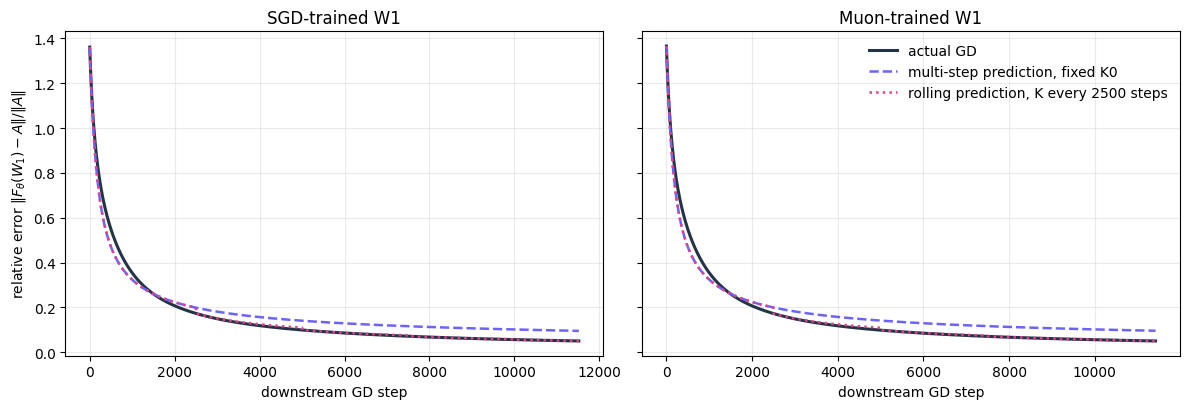

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

ROLLING_INTERVAL = 2500


def train_blackbox_with_snapshots(W1, A, rolling_interval=ROLLING_INTERVAL):
    params = init_blackbox_params()
    opt = torch.optim.SGD(params, lr=BB_LR)
    norm_A = A.norm().item()
    actual_errors, snapshots = [], []

    for step in range(BB_MAX_STEPS + 1):
        with torch.no_grad():
            rel_error = (blackbox_forward(params, W1) - A).norm().item() / norm_A
            actual_errors.append(rel_error)
        if step % rolling_interval == 0 or rel_error <= BB_THRESHOLD or step == BB_MAX_STEPS:
            snapshots.append((step, flatten_params(params)))
        if rel_error <= BB_THRESHOLD or step == BB_MAX_STEPS:
            break

        error_matrix = blackbox_forward(params, W1) - A
        loss = 0.5 * (error_matrix ** 2).sum() / (norm_A**2)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    return torch.tensor(actual_errors), snapshots


def frozen_kernel_prediction(theta_anchor, W1, A, horizon):
    J, e = jacobian_and_error_from_theta(theta_anchor, W1, A)
    K = J @ J.T
    scaled_lr = BB_LR / (A.norm().item() ** 2)
    predicted = []
    current_e = e.clone()
    norm_A = A.norm().item()

    for _ in range(horizon + 1):
        predicted.append(current_e.norm().item() / norm_A)
        current_e = current_e - scaled_lr * (K @ current_e)

    lambda_eff = (e @ (K @ e) / (e @ e)).item()
    return torch.tensor(predicted), lambda_eff


def rolling_kernel_prediction(W1, A, snapshots, total_steps):
    predicted = torch.empty(total_steps + 1)
    for (start, theta_anchor), (end, _) in zip(snapshots[:-1], snapshots[1:]):
        segment, _ = frozen_kernel_prediction(theta_anchor, W1, A, end - start)
        predicted[start:end + 1] = segment
    return predicted


def blackbox_multistep_case(label, W1):
    actual, snapshots = train_blackbox_with_snapshots(W1, A)
    total_steps = len(actual) - 1
    frozen, lambda_eff_0 = frozen_kernel_prediction(snapshots[0][1], W1, A, total_steps)
    rolling = rolling_kernel_prediction(W1, A, snapshots, total_steps)
    return dict(label=label, actual=actual.cpu(), frozen=frozen.cpu(), rolling=rolling.cpu(), lambda_eff_0=lambda_eff_0)


def run_blackbox_multistep_prediction_plot():
    cases = [
        blackbox_multistep_case("SGD-trained W1", sgd_run["W1"]),
        blackbox_multistep_case("Muon-trained W1", muon_run["W1"]),
    ]

    print("\n" + "=" * 72)
    print("Black-box downstream: multi-step Jacobian prediction")
    print(f"  fixed K0 vs rolling K_t every {ROLLING_INTERVAL} steps")
    print("=" * 72)
    for case in cases:
        frozen_mae = (case["actual"] - case["frozen"]).abs().mean().item()
        rolling_mae = (case["actual"] - case["rolling"]).abs().mean().item()
        print(f"\n  [{case['label']}]")
        print(
            f"    final actual/frozen/rolling = "
            f"{case['actual'][-1]:.6f} / {case['frozen'][-1]:.6f} / {case['rolling'][-1]:.6f}"
        )
        print(f"    mean abs curve error: frozen={frozen_mae:.3e}, rolling={rolling_mae:.3e}")
        print(f"    lambda_eff at step 0: {case['lambda_eff_0']:.3e}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
    for ax, case in zip(axes, cases):
        steps = range(len(case["actual"]))
        ax.plot(steps, case["actual"], label="actual GD", lw=2.2, color="#243447")
        ax.plot(steps, case["frozen"], label="multi-step prediction, fixed K0", lw=1.8, ls="--", color="#6C63FF")
        ax.plot(
            steps,
            case["rolling"],
            label=f"rolling prediction, K every {ROLLING_INTERVAL} steps",
            lw=1.8,
            ls=":",
            color="#E83E8C",
        )
        ax.set_title(case["label"])
        ax.set_xlabel("downstream GD step")
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel(r"relative error $\|F_\theta(W_1)-A\|/\|A\|$")
    axes[1].legend(frameon=False, loc="upper right")
    fig.tight_layout()
    plt.show()


run_blackbox_multistep_prediction_plot()


## 扩展：从矩阵目标到样本损失

前面的黑盒下游直接拟合一个目标矩阵：
$$F_\theta(W_1)\approx A.$$
这适合把推导写得紧凑，但实际监督学习通常不是比较两个矩阵，而是比较一批样本上的预测与标签。下面分两步扩展：先把同一个 MSE 问题写成样本形式，再只替换输出损失为交叉熵。

### 1. 黑盒下游的样本形式：仍使用 MSE

给定样本 $(x_i,y_i)$，冻结上游表征
$$h_i=W_1x_i,$$
让一般的可微下游输出
$$\hat y_i=f_\theta(h_i).$$
设每个输出属于 $\mathbb R^m$。把所有样本的预测和目标分别组成矩阵
$$
\hat Y(\theta):=
\begin{bmatrix}
f_\theta(h_1)^\top\\
\vdots\\
f_\theta(h_n)^\top
\end{bmatrix}
\in\mathbb R^{n\times m},
\qquad
Y:=
\begin{bmatrix}
y_1^\top\\
\vdots\\
y_n^\top
\end{bmatrix}
\in\mathbb R^{n\times m}.
$$
再把样本维和输出维一起展平为误差向量
$$
e(\theta)=\operatorname{vec}\!\left(\hat Y(\theta)-Y\right),
\qquad
J_t=\left.\frac{\partial e}{\partial\theta}\right|_{\theta_t}.
$$
本文的 $\operatorname{vec}$ 按样本顺序依次拼接矩阵的各行。
样本平均 MSE 为
$$L(\theta)=\frac1{2n}\|e(\theta)\|^2,$$
所以
$$\nabla_\theta L(\theta_t)=\frac1nJ_t^\top e_t.$$
一步 GD 后，先对黑盒输出做局部线性化：
$$
\Delta\theta_t=-\frac{\eta}{n}J_t^\top e_t,
\qquad
e_{t+1}\approx e_t+J_t\Delta\theta_t
=\left(I-\frac{\eta}{n}J_tJ_t^\top\right)e_t.
$$
这与前面矩阵黑盒的推导完全相同；区别只是原来误差向量来自 $F_\theta(W_1)-A$，现在来自样本预测矩阵 $\hat Y-Y$ 的向量化。上游 $W_1$ 仍通过 $h_i=W_1x_i$ 进入 $J_t$，因而改变 $J_tJ_t^\top$ 的谱和下游收敛速度。


### 2. 保留样本形式，把输出损失换成 CE

令黑盒下游为每个样本输出 $C$ 维 logits：$z_i(\theta)=f_\theta(h_i)\in\mathbb R^C$。将 logits、softmax 概率和 one-hot 标签分别组成矩阵
$$
Z:=
\begin{bmatrix}z_1(\theta)^\top\\ \vdots\\ z_n(\theta)^\top\end{bmatrix},
\qquad
P:=
\begin{bmatrix}\operatorname{softmax}(z_1(\theta))^\top\\ \vdots\\ \operatorname{softmax}(z_n(\theta))^\top\end{bmatrix},
\qquad
Y:=
\begin{bmatrix}\operatorname{onehot}(y_1)^\top\\ \vdots\\ \operatorname{onehot}(y_n)^\top\end{bmatrix},
\qquad
Z,P,Y\in\mathbb R^{n\times C}.
$$
在第 $t$ 步，用 $Z_t$ 和 $P_t$ 表示 $Z$ 和 $P$ 在 $\theta_t$ 处的取值。
沿用上节的 $\operatorname{vec}$ 约定，只将残差矩阵展平：
$$
E_t:=P_t-Y,
\qquad
e_t:=\operatorname{vec}(E_t),
\qquad
J_t:=\left.
\frac{\partial\,\operatorname{vec}(Z)}{\partial\theta}
\right|_{\theta_t}.
$$
这里沿用 MSE 小节的 $e_t$ 符号：MSE 下 $e_t$ 是预测减目标，CE 下 $e_t$ 是 softmax 概率减 one-hot 标签。

对平均交叉熵，
$$
\nabla_{\operatorname{vec}(Z)}L=\frac1ne_t,
\qquad
\nabla_\theta L(\theta_t)=\frac1nJ_t^\top e_t.
$$
一步 GD 后，局部线性化 logits：
$$
\Delta\theta_t=-\frac{\eta}{n}J_t^\top e_t,
\qquad
\Delta\operatorname{vec}(Z_t)\approx J_t\Delta\theta_t
=-\frac{\eta}{n}J_tJ_t^\top e_t.
$$
对第 $i$ 个样本，softmax 的第 $c$ 个分量为
$$
p_{i,c}
=\frac{\exp(z_{i,c})}{\sum_a\exp(z_{i,a})}.
$$
对第 $d$ 个 logit 求导：
$$
\begin{aligned}
\frac{\partial p_{i,c}}{\partial z_{i,d}}
&=\frac{\delta_{cd}\exp(z_{i,c})\sum_a\exp(z_{i,a})
-\exp(z_{i,c})\exp(z_{i,d})}
{\left(\sum_a\exp(z_{i,a})\right)^2}\\
&=p_{i,c}\left(\delta_{cd}-p_{i,d}\right).
\end{aligned}
$$
因此该样本的 softmax Jacobian 为
$$
\frac{\partial p_i}{\partial z_i}
=\operatorname{diag}(p_i)-p_ip_i^\top.
$$
由于标签不随 logits 改变，$E_t=P_t-Y$ 对 logits 的 Jacobian 与 $P_t$ 相同。将各样本的 Jacobian 按上述样本顺序排列，记
$$
S_t:=\frac{\partial e_t}{\partial\,\operatorname{vec}(Z_t)}
=\operatorname{blockdiag}\!\left(
\operatorname{diag}(p_{t,i})-p_{t,i}p_{t,i}^\top
\right)_i.
$$
因此
$$
\begin{aligned}
e_{t+1}
&\approx e_t+S_t\Delta\operatorname{vec}(Z_t)\\
&=e_t-\frac{\eta}{n}S_tJ_tJ_t^\top e_t\\
&=\left(I-\frac{\eta}{n}S_tJ_tJ_t^\top\right)e_t.
\end{aligned}
$$
这正是 MSE 递推
$$
e_{t+1}\approx
\left(I-\frac{\eta}{n}J_tJ_t^\top\right)e_t
$$
在 CE 下的对应形式：输出侧多了 softmax Jacobian $S_t$。

### 3. 预测 CE loss 下降

到这里，已经可以局部预测 CE 输出残差如何变化。除此之外，我们还希望回答另一个问题：**能否只根据当前点的信息，从理论上预测一步 GD 会让 CE loss 下降多少？** 为此需要 CE loss 关于参数更新的二阶局部模型。

记
$$
g_t=\nabla_\theta L(\theta_t)=\frac1nJ_t^\top e_t.
$$
对任意小参数扰动 $\Delta\theta$，冻结当前 $J_t$，有
$$
\Delta\operatorname{vec}(Z)\approx J_t\Delta\theta.
$$
CE loss 在 logits 空间中的二阶局部展开为
$$
L(Z_t+\Delta Z)
\approx L_t
+\frac1n e_t^\top\Delta\operatorname{vec}(Z)
+\frac1{2n}\Delta\operatorname{vec}(Z)^\top
S_t\Delta\operatorname{vec}(Z).
$$
代入 $\Delta\operatorname{vec}(Z)\approx J_t\Delta\theta$：
$$
L(\theta_t+\Delta\theta)
\approx L_t+g_t^\top\Delta\theta
+\frac12\Delta\theta^\top G_t\Delta\theta,
\qquad
G_t:=\frac1nJ_t^\top S_tJ_t.
$$
这个参数空间中的算子 $G_t$ 称为广义 Gauss--Newton（GN）算子。

因此对一步 GD，$\Delta\theta=-\eta g_t$，理论预测的 loss 下降量为
$$
L_t-L_{t+1}
\approx
\eta\|g_t\|^2
-\frac12\eta^2g_t^\top G_tg_t.
$$
最后说明 $G_t$ 与完整 Hessian 的关系。把 $\operatorname{vec}(Z)$ 的第 $k$ 个分量记为 $z_k$，用 $a,b$ 表示参数坐标，则
$$
J_{t,ka}=\frac{\partial z_k}{\partial\theta_a},
\qquad
S_{t,k\ell}=\frac{\partial e_{t,k}}{\partial z_\ell},
\qquad
g_{t,a}=\frac1nJ_{t,ka}e_{t,k}.
$$
这里重复指标默认求和。再对 $\theta_b$ 求导：
$$
\begin{aligned}
\frac{\partial g_{t,a}}{\partial\theta_b}
&=\frac1nJ_{t,ka}
  \frac{\partial e_{t,k}}{\partial\theta_b}
  +\frac1n e_{t,k}
  \frac{\partial J_{t,ka}}{\partial\theta_b}\\
&=\frac1nJ_{t,ka}S_{t,k\ell}J_{t,\ell b}
  +\frac1n e_{t,k}
  \frac{\partial^2z_k}{\partial\theta_a\partial\theta_b}.
\end{aligned}
$$
第一项正是 $G_t=J_t^\top S_tJ_t/n$，所以
$$
\nabla_\theta^2L
=G_t
+\frac1n\sum_k e_{t,k}\nabla_\theta^2z_k.
$$
第二项来自 logits 本身关于参数的二阶变化，因此称为模型二阶项。对一般黑盒，它通常不为零，GN 只保留 Hessian 的第一项。若采用 $z=Bh$，则 $\nabla_B^2z_k=0$，所以当前点的 GN 等于完整 Hessian。由于 $S_t$ 仍随预测改变，冻结 GN 的多步预测并非全局精确。


### 4. 可运行检查：同一批样本上的 CE 线性探针

接下来用一个可运行实验检查上述推导。实验不重新训练 Phase 1，而是直接复用主实验得到的 `sgd_run["W1"]` 与 `muon_run["W1"]`。固定同一批输入和同一个教师标签，只改变 $h=W_1x$ 中的 $W_1$，然后检查三件事：

1. 当前点的 GN 二次模型能否预测一步 CE 下降；
2. 两种表征接同样的 CE 探针后，真实训练曲线有何差异；
3. 两者在 $B=0$ 处的 GN 谱有何差异。

一步预测直接使用上面得到的 CE loss 下降公式。它检验的是当前点的二阶局部模型；训练多步以后 $p_t$ 和 $S_t$ 已改变，不能继续把初始 GN 当作精确的固定核。


In [8]:
import torch.nn.functional as F

CE_CLASSES = 8
CE_SAMPLES = 4096
CE_LR = 5e-1
CE_STEPS = 80


def make_ce_dataset(n=CE_SAMPLES, classes=CE_CLASSES, seed=SEED + 7):
    # 同一组 X、标签分别接到 SGD/Muon 得到的 W1，保证比较只改变表征。
    gen = torch.Generator(device="cuda").manual_seed(seed)
    X = torch.randn(n, D, generator=gen, device="cuda")
    teacher = torch.randn(classes, D, generator=gen, device="cuda") / math.sqrt(D)
    y = (X @ teacher.T).argmax(dim=1)
    return X, y


def ce_loss(H, B, y):
    return F.cross_entropy(H @ B.T, y, reduction="mean")


def build_ce_gn(H, B):
    # vec(B) 参数空间中的 J^T S J，维度为 (classes*d) x (classes*d)。
    with torch.no_grad():
        P = (H @ B.T).softmax(dim=1)
        n, d = H.shape
        classes = B.shape[0]
        G = torch.empty(classes * d, classes * d, device=H.device, dtype=H.dtype)
        for a in range(classes):
            for b in range(classes):
                weight = P[:, a] * ((1.0 if a == b else 0.0) - P[:, b])
                G[a * d:(a + 1) * d, b * d:(b + 1) * d] = (H * weight[:, None]).T @ H / n
        return 0.5 * (G + G.T)


def one_step_ce_gn_check(H, y, lr=CE_LR):
    B = torch.zeros(CE_CLASSES, H.shape[1], device=H.device, requires_grad=True)
    loss0 = ce_loss(H, B, y)
    g = torch.autograd.grad(loss0, B)[0].detach().reshape(-1)
    G = build_ce_gn(H, B.detach())
    predicted_drop = lr * g.dot(g) - 0.5 * lr**2 * g.dot(G @ g)

    with torch.no_grad():
        B1 = B.detach() - lr * g.reshape_as(B)
        actual_drop = loss0.detach() - ce_loss(H, B1, y)
    return float(actual_drop), float(predicted_drop), G


def train_ce_probe(H, y, steps=CE_STEPS, lr=CE_LR):
    B = torch.zeros(CE_CLASSES, H.shape[1], device=H.device, requires_grad=True)
    optimizer = torch.optim.SGD([B], lr=lr)
    losses = []
    for step in range(steps + 1):
        loss = ce_loss(H, B, y)
        losses.append(float(loss.detach()))
        if step == steps:
            break
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    return losses


one-step CE decrease: actual vs local GN prediction
  SGD-trained W1    : actual=0.122983, predicted=0.122995, rel_error=0.01%, GN_flatness=0.7968
  Muon-trained W1   : actual=0.124568, predicted=0.124580, rel_error=0.01%, GN_flatness=0.7980


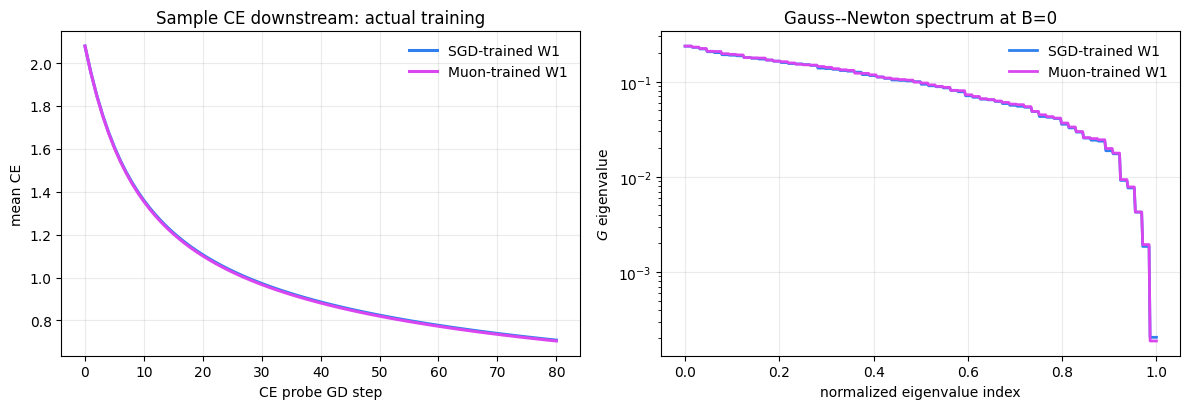

SGD-trained W1    : CE 2.0794 -> 0.7078, drop=1.3716
Muon-trained W1   : CE 2.0794 -> 0.7040, drop=1.3754


In [9]:
X_ce, y_ce = make_ce_dataset()
ce_cases = {
    "SGD-trained W1": X_ce @ sgd_run["W1"].T,
    "Muon-trained W1": X_ce @ muon_run["W1"].T,
}

gn_eigenvalues = {}
print("one-step CE decrease: actual vs local GN prediction")
for label, H_ce in ce_cases.items():
    actual, predicted, G = one_step_ce_gn_check(H_ce, y_ce)
    rel_error = abs(predicted - actual) / max(abs(actual), 1e-12)
    eigenvalues = torch.linalg.eigvalsh(G).clamp_min(0)
    active = eigenvalues[eigenvalues > 1e-10 * eigenvalues.max()]
    p = active / active.sum().clamp_min(1e-30)
    flatness = float(torch.exp(-(p * torch.log(p.clamp_min(1e-30))).sum()).item() / len(active))
    gn_eigenvalues[label] = active.cpu()
    print(
        f"  {label:18s}: actual={actual:.6f}, predicted={predicted:.6f}, "
        f"rel_error={100 * rel_error:.2f}%, GN_flatness={flatness:.4f}"
    )

ce_curves = {label: train_ce_probe(H_ce, y_ce) for label, H_ce in ce_cases.items()}
colors = {"SGD-trained W1": "#2F80ED", "Muon-trained W1": "#D946EF"}

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
for label, curve in ce_curves.items():
    axes[0].plot(curve, label=label, lw=2.2, color=colors[label])
axes[0].set_xlabel("CE probe GD step")
axes[0].set_ylabel("mean CE")
axes[0].set_title("Sample CE downstream: actual training")
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False)

for label, eigenvalues in gn_eigenvalues.items():
    rank = torch.linspace(0, 1, len(eigenvalues))
    axes[1].semilogy(rank, eigenvalues.flip(0), label=label, lw=2.0, color=colors[label])
axes[1].set_xlabel("normalized eigenvalue index")
axes[1].set_ylabel(r"$G$ eigenvalue")
axes[1].set_title("Gauss--Newton spectrum at B=0")
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

for label, curve in ce_curves.items():
    print(f"{label:18s}: CE {curve[0]:.4f} -> {curve[-1]:.4f}, drop={curve[0] - curve[-1]:.4f}")


### 5. 公式对照表

| 下游形式 | 输出残差的局部递推 | 参数空间中的对应算子 |
|---|---|---|
| 下游为单线性层，矩阵 MSE | $E_{t+1}=E_t(I-\eta W_1^\top W_1)$ | $W_1^\top W_1$ |
| 下游为黑盒，矩阵 MSE | $e_{t+1}\approx\left(I-\frac{\eta}{\|A\|_F^2}J_tJ_t^\top\right)e_t$ | $J_t^\top J_t/\|A\|_F^2$ |
| 下游为黑盒，样本 MSE | $e_{t+1}\approx\left(I-\frac{\eta}{n}J_tJ_t^\top\right)e_t$ | $J_t^\top J_t/n$ |
| 下游为黑盒，样本 CE | $e_{t+1}\approx\left(I-\frac{\eta}{n}S_tJ_tJ_t^\top\right)e_t$ | $G_t=J_t^\top S_tJ_t/n$ |


## 扩展：通过相邻方案交替推广到多层 MLP

前面的章节冻结了上游编码器，并将第二阶段的速度归因于 $JJ^\top$ 的谱。这里我们把这一视角推广到带激活函数和样本损失的完整多层 MLP，并给出一个充分条件：在**最后一层固定使用 SGD** 时，**对可训练前缀使用 Muon 的整体速度快于全 SGD**。

### 设定

令
$$
f_\theta(x)=W_L\,\sigma\bigl(W_{L-1}\,\sigma(\cdots\sigma(W_1x)\cdots)\bigr),
$$
其中 $\sigma$ 是固定的逐元素激活函数（可运行检查使用 $\tanh$ 和 $L=5$）。给定一批样本 $\{(x_j,y_j)\}_{j=1}^n$，记预测为 $\hat y_j=f_\theta(x_j)$，平均平方残差为
$$
L(\theta)=\frac1{2n}\sum_{j=1}^n\|\hat y_j-y_j\|_2^2.
$$
（将残差替换为 $p-y$，并将 $JJ^\top$ 替换为上一节中的 $SJJ^\top$ / Gauss--Newton 形式后，CE 情形完全相同；这里以 MSE 为主线。）

### 过渡方案序列

输出层 $W_L$ **始终**使用 SGD 训练。Muon 只允许用于前缀 $W_1,\ldots,W_{L-1}$。对 $k=0,\ldots,L-1$，定义
$$
\Pi_k:\quad
\text{第 }1,\ldots,k\text{ 层使用 Muon，}\quad
\text{第 }k+1,\ldots,L\text{ 层使用 SGD}
$$
（约定 $k=0$ 表示全 SGD）。特别地，$\Pi_0$ 是全 SGD，$\Pi_{L-1}$ 则除最后一层外全部使用 Muon。要证明 $T(\Pi_{L-1})<T(\Pi_0)$，只需对每个 $i=0,\ldots,L-2$ 证明相邻不等式 $T(\Pi_{i+1})<T(\Pi_i)$，再将它们串联起来。

当 $L=5$ 时，序列为：

| 方案 | $W_1$ | $W_2$ | $W_3$ | $W_4$ | $W_5$ |
|---|---|---|---|---|---|
| $\Pi_0$ | SGD | SGD | SGD | SGD | SGD |
| $\Pi_1$ | Muon | SGD | SGD | SGD | SGD |
| $\Pi_2$ | Muon | Muon | SGD | SGD | SGD |
| $\Pi_3$ | Muon | Muon | Muon | SGD | SGD |
| $\Pi_4$ | Muon | Muon | Muon | Muon | SGD |

### 相邻比较：上游与下游

固定 $i\in\{0,\ldots,L-2\}$，比较 $\Pi_i$ 与 $\Pi_{i+1}$。将网络划分为：
- **上游** $U$：第 $1,\ldots,i+1$ 层；
- **下游** $D$：第 $i+2,\ldots,L$ 层。

两种方案都在第 $1,\ldots,i$ 层使用 Muon，并在 $D$（包括最后一层）上使用 SGD。二者的**唯一**区别是上游边界层 $i+1$ 所用的优化器：$\Pi_i$ 使用 SGD，而 $\Pi_{i+1}$ 使用 Muon。


### 交替半步（可分解的动力学）

标准联合训练在同一步中更新 $U$ 和 $D$，因此损失变化无法干净地拆成上游贡献与下游贡献。把每个联合步骤替换为在同一批数据上进行的两个半步：

1. **上游半步。** 冻结 $D$，只更新 $U$。记录
   $$\Delta L^{\mathrm{up}} := L_{\mathrm{after\,up}}-L_{\mathrm{before}}.$$
2. **重新送入。** 使用更新后的上游重新计算前向传播（下游的输入表示已经改变）。
3. **下游半步。** 冻结 $U$，只更新 $D$。记录
   $$\Delta L^{\mathrm{down}} := L_{\mathrm{after\,down}}-L_{\mathrm{after\,up}}.$$

于是完整一步的变化形成望远镜求和：
$$\Delta L = \Delta L^{\mathrm{up}}+\Delta L^{\mathrm{down}}.$$
定义三条曲线
$$
L_t,\qquad
C^{\mathrm{up}}_t=\sum_{s\le t}\Delta L^{\mathrm{up}}_s,\qquad
C^{\mathrm{down}}_t=\sum_{s\le t}\Delta L^{\mathrm{down}}_s,
$$
则 $L_t=L_0+C^{\mathrm{up}}_t+C^{\mathrm{down}}_t$。（这与 $\tau$ 调度 notebook 中的交替直觉相同，只是这里专门采用 $\tau=1$ 的半步，并显式拆分累计量。）

我们**并不**声称交替动力学等同于联合 GD。交替过程是用于证明的动力学，因为它使上游/下游的核算精确成立。

### 控制上游下降量

把下降量写成正数 $\delta^{\mathrm{up}}:=-\Delta L^{\mathrm{up}}$。在上游半步中，两种方案都会为 $U$ 计算更新方向（边界层使用 SGD 或 Muon；共享的前面各层使用 Muon）。沿该方向用因子 $\alpha\ge 0$ 缩放整个上游步长，并选择 $\alpha$，使实际下降量近似匹配：
$$
\bigl|\delta^{\mathrm{up}}_t(\Pi_{i+1})-\delta^{\mathrm{up}}_t(\Pi_i)\bigr|\le\varepsilon_t.
$$
（代码中：以上游方案 $\Pi_i$ 的下降量为目标，对 $\Pi_{i+1}$ 的 $\alpha$ 做线搜索。）求和后得到上游累计差距的界：
$$
\bigl|C^{\mathrm{up}}_T(\Pi_{i+1})-C^{\mathrm{up}}_T(\Pi_i)\bigr|\le B^{\mathrm{up}}_T:=\sum_{t\le T}\varepsilon_t.
$$


### 约化到冻结上游的 $JJ^\top$ 情形

完成上游半步并重新送入后，下游半步冻结上游表示
$$
h_j = U(x_j)
$$
并且只更新下游映射 $f_D(h)$。这恰好就是前一节的样本黑盒设定：令
$$
e=\operatorname{vec}(\hat Y-Y),\qquad J=\partial e/\partial\theta_D,
$$
则在 $D$ 上执行一步 GD 满足
$$
e^+\approx\Bigl(I-\frac{\eta}{n}JJ^\top\Bigr)e,\qquad
\lambda_{\mathrm{eff}}=\frac{e^\top JJ^\top e}{e^\top e},
$$
局部损失下降由 $\lambda_{\mathrm{eff}}$ 控制（在小步长假设下，再加上通常的 $O(\eta^2)$ 余项）。

两种方案的区别只来自 $U$ 内部边界层 $i+1$ 的更新方式。沿用第一阶段的 Muon-vs-SGD 权衡叙述：Muon 可能付出单步损失代价，但会为线性 / 黑盒恢复产生条件更好的表示；因此使用 Muon 的边界层会得到更有利的 $J(h)J(h)^\top$ 谱，从而产生更大的有效速率 $\lambda_{\mathrm{eff}}$。累计额外的下游下降量，得到增益
$$
G_T := \bigl(C^{\mathrm{down}}_T(\Pi_i)-C^{\mathrm{down}}_T(\Pi_{i+1})\bigr)
$$
（损失下降时，两个 $C^{\mathrm{down}}$ 都为负；$G_T>0$ 表示 $\Pi_{i+1}$ 在下游半步中下降得更多）。

### 判据

如果下游增益超过受控的上游差异，
$$
G_T > B^{\mathrm{up}}_T,
$$
那么
$$
L_T(\Pi_{i+1})-L_T(\Pi_i)
= \bigl(C^{\mathrm{up}}_T(\Pi_{i+1})-C^{\mathrm{up}}_T(\Pi_i)\bigr)
+ \bigl(C^{\mathrm{down}}_T(\Pi_{i+1})-C^{\mathrm{down}}_T(\Pi_i)\bigr)
< 0.
$$
因此，在相同的交替步数 $T$ 下，$\Pi_{i+1}$ 达到更低的损失。将每个相邻对 $i=0,\ldots,L-2$ 串联起来，就可在这些条件下得到 $\Pi_{L-1}$ 快于 $\Pi_0$。

换言之，这就是第一阶段同一套 Muon-vs-SGD 权衡，只是改写成交替半步形式：可能出现的**匹配后上游半步差距**（代价）可以由下游半步上更大的**冻结上游 $JJ^\top$ 速率差距**（收益）偿还。不等式 $G_T > B^{\mathrm{up}}_T$ 正是“收益压过代价”的检验。

### 充分条件（所作假设）

1. 半步步长足够小，使 $JJ^\top$ 中的一阶残差映射能够控制下游损失变化。
2. 上游步长匹配使 $B^{\mathrm{up}}_T$ 有限，并且相对于下游差距足够小。
3. 边界层上的 Muon 更新对下游 $\lambda_{\mathrm{eff}}$ 的改善（或至少不破坏）足够大，使整个运行过程中 $G_T>B^{\mathrm{up}}_T$。
4. 比较结论针对上述交替动力学；是否能把这一排序迁移到联合训练，需要经验验证，不在该检验范围内。

下面的单元运行一个采用样本 MSE 的 $L=5$ MLP，在匹配上游下降量的条件下，**比较每一组相邻方案** $(\Pi_i,\Pi_{i+1})$（$i=0,\ldots,3$），为每一对绘制三条曲线，并抽查下游 $\lambda_{\mathrm{eff}}$。


In [10]:
# Multi-layer MLP adjacent-scheme check (sample MSE, alternating half-steps).
# L=5, last layer always SGD; compare every adjacent pair Pi_i vs Pi_{i+1}.

%matplotlib inline
import matplotlib.pyplot as plt

MLP_D_IN = 32
MLP_D_HID = 32
MLP_D_OUT = 8
MLP_L = 5
MLP_N = 512
MLP_LR = 3e-2
MLP_STEPS = 150
MLP_SEED = 0
MLP_LAMBDA_EVERY = 25
# Muon prefix length k in {0,...,L-1}; last layer index L-1 is never Muon.
MLP_ADJ_PAIRS = list(range(MLP_L - 1))  # i = 0,1,2,3  ->  (Pi_i, Pi_{i+1})


In [11]:
def mlp_layer_dims(d_in=MLP_D_IN, d_hid=MLP_D_HID, d_out=MLP_D_OUT, depth=MLP_L):
    return [d_in] + [d_hid] * (depth - 1) + [d_out]


def make_mlp_regression(n=MLP_N, seed=MLP_SEED + 21):
    dims = mlp_layer_dims()
    gen = torch.Generator(device="cuda").manual_seed(seed)
    X = torch.randn(n, dims[0], generator=gen, device="cuda")
    set_seed(seed + 1)
    teacher = []
    for din, dout in zip(dims[:-1], dims[1:]):
        teacher.append(torch.randn(dout, din, device="cuda") / math.sqrt(din))
    with torch.no_grad():
        h = X
        for k, W in enumerate(teacher):
            h = h @ W.T
            if k < len(teacher) - 1:
                h = torch.tanh(h)
        Y = h
    return X, Y


def init_mlp_layers(seed=MLP_SEED + 3):
    set_seed(seed)
    dims = mlp_layer_dims()
    layers = []
    for din, dout in zip(dims[:-1], dims[1:]):
        W = (torch.randn(dout, din, device="cuda") / math.sqrt(din)).requires_grad_(True)
        layers.append(W)
    assert len(layers) == MLP_L
    return layers


def mlp_forward(layers, X):
    h = X
    for k, W in enumerate(layers):
        h = h @ W.T
        if k < len(layers) - 1:
            h = torch.tanh(h)
    return h


def mlp_mse(layers, X, Y):
    return 0.5 * ((mlp_forward(layers, X) - Y) ** 2).mean()


def clone_mlp_layers(layers):
    return [W.detach().clone().requires_grad_(True) for W in layers]


def scheme_muon_mask(k, depth=MLP_L):
    """Pi_k: Muon on first k layers; last layer is always SGD."""
    return [j < k and j < depth - 1 for j in range(depth)]


def apply_update_dirs(layers, dirs, alpha, mask):
    with torch.no_grad():
        for W, direction, active in zip(layers, dirs, mask):
            if active and direction is not None:
                W.add_(direction, alpha=-alpha)


def mlp_loss_after_scaled_step(layers, dirs, mask, alpha, X, Y):
    backup = [W.detach().clone() for W in layers]
    apply_update_dirs(layers, dirs, alpha, mask)
    with torch.no_grad():
        value = mlp_mse(layers, X, Y).item()
    with torch.no_grad():
        for W, snap in zip(layers, backup):
            W.copy_(snap)
    return value


def match_upstream_alpha(layers, dirs, up_mask, X, Y, loss0, target_drop, base_lr, max_tries=14):
    """Line-search alpha so loss0 - L(alpha) ≈ target_drop (>= 0)."""
    if target_drop <= 0:
        return 0.0
    alpha = base_lr
    best_alpha, best_err = 0.0, abs(target_drop)
    for _ in range(max_tries):
        loss_alpha = mlp_loss_after_scaled_step(layers, dirs, up_mask, alpha, X, Y)
        drop = loss0 - loss_alpha
        err = abs(drop - target_drop)
        if err < best_err:
            best_err, best_alpha = err, alpha
        if drop < 0.5 * target_drop:
            alpha *= 1.8
        elif drop > 1.5 * target_drop:
            alpha *= 0.55
        else:
            if drop > 1e-12:
                alpha = alpha * (target_drop / drop)
                loss_alpha = mlp_loss_after_scaled_step(layers, dirs, up_mask, alpha, X, Y)
                err = abs((loss0 - loss_alpha) - target_drop)
                if err < best_err:
                    best_err, best_alpha = err, alpha
            break
    return best_alpha


def upstream_dirs(layers, grads, muon_mask, up_mask):
    dirs = []
    for j in range(len(layers)):
        if not up_mask[j] or grads[j] is None:
            dirs.append(None)
        elif muon_mask[j]:
            dirs.append(muon_direction(grads[j]))
        else:
            dirs.append(grads[j])
    return dirs


def estimate_downstream_lambda_eff(layers, X, Y, up_count):
    """Rayleigh quotient e^T J J^T e / ||e||^2 for downstream params, upstream frozen."""
    upstream = [W.detach() for W in layers[:up_count]]
    downstream = [W.detach().clone() for W in layers[up_count:]]
    if not downstream:
        return float("nan")

    def residual_from_flat(flat):
        params, offset = [], 0
        for W in downstream:
            n = W.numel()
            params.append(flat[offset:offset + n].reshape_as(W))
            offset += n
        h = X
        for W in upstream:
            h = torch.tanh(h @ W.T)
        for k, W in enumerate(params):
            h = h @ W.T
            if k < len(params) - 1:
                h = torch.tanh(h)
        return (h - Y).reshape(-1)

    flat0 = torch.cat([W.reshape(-1) for W in downstream])
    e = residual_from_flat(flat0).detach()
    flat = flat0.detach().requires_grad_(True)
    g = torch.autograd.grad((residual_from_flat(flat) * e).sum(), flat)[0]
    return float((g @ g) / (e @ e).clamp_min(1e-30))


In [12]:
def train_adjacent_halfsteps(
    i,
    X,
    Y,
    init_layers,
    steps=MLP_STEPS,
    lr=MLP_LR,
    lambda_every=MLP_LAMBDA_EVERY,
):
    """Paired Pi_i vs Pi_{i+1} under alternating Up/Down half-steps with matched upstream drops."""
    layers_a = clone_mlp_layers(init_layers)  # Pi_i
    layers_b = clone_mlp_layers(init_layers)  # Pi_{i+1}
    muon_a = scheme_muon_mask(i)
    muon_b = scheme_muon_mask(i + 1)
    assert not muon_a[-1] and not muon_b[-1], "last layer must stay SGD"
    up_count = i + 1
    up_mask = [j < up_count for j in range(MLP_L)]
    down_mask = [j >= up_count for j in range(MLP_L)]

    hist = dict(
        L_a=[], L_b=[], Cup_a=[], Cup_b=[], Cdown_a=[], Cdown_b=[],
        up_gap=[], lambda_a=[], lambda_b=[], lambda_steps=[],
        i=i, muon_a=muon_a, muon_b=muon_b,
    )
    Cup_a = Cup_b = Cdown_a = Cdown_b = 0.0

    def snapshot(La, Lb):
        hist["L_a"].append(La)
        hist["L_b"].append(Lb)
        hist["Cup_a"].append(Cup_a)
        hist["Cup_b"].append(Cup_b)
        hist["Cdown_a"].append(Cdown_a)
        hist["Cdown_b"].append(Cdown_b)

    La = mlp_mse(layers_a, X, Y).item()
    Lb = mlp_mse(layers_b, X, Y).item()
    snapshot(La, Lb)

    for t in range(steps):
        for W in layers_a:
            W.grad = None
        loss_a0 = mlp_mse(layers_a, X, Y)
        loss_a0.backward()
        grads_a = [layers_a[j].grad.detach().clone() if up_mask[j] else None for j in range(MLP_L)]
        dirs_a = upstream_dirs(layers_a, grads_a, muon_a, up_mask)
        apply_update_dirs(layers_a, dirs_a, lr, up_mask)
        with torch.no_grad():
            La_up = mlp_mse(layers_a, X, Y).item()
        target_drop = loss_a0.item() - La_up
        Cup_a += La_up - loss_a0.item()

        for W in layers_b:
            W.grad = None
        loss_b0 = mlp_mse(layers_b, X, Y)
        loss_b0.backward()
        grads_b = [layers_b[j].grad.detach().clone() if up_mask[j] else None for j in range(MLP_L)]
        dirs_b = upstream_dirs(layers_b, grads_b, muon_b, up_mask)
        alpha_b = match_upstream_alpha(
            layers_b, dirs_b, up_mask, X, Y, loss_b0.item(), target_drop, lr
        )
        apply_update_dirs(layers_b, dirs_b, alpha_b, up_mask)
        with torch.no_grad():
            Lb_up = mlp_mse(layers_b, X, Y).item()
        Cup_b += Lb_up - loss_b0.item()
        hist["up_gap"].append(abs(target_drop - (loss_b0.item() - Lb_up)))

        for layers, L_up, key in ((layers_a, La_up, "a"), (layers_b, Lb_up, "b")):
            for W in layers:
                W.grad = None
            for j, W in enumerate(layers):
                W.requires_grad_(down_mask[j])
            loss_mid = mlp_mse(layers, X, Y)
            loss_mid.backward()
            dirs_down = [
                layers[j].grad.detach().clone() if down_mask[j] else None for j in range(MLP_L)
            ]
            apply_update_dirs(layers, dirs_down, lr, down_mask)
            for W in layers:
                W.requires_grad_(True)
            with torch.no_grad():
                L_new = mlp_mse(layers, X, Y).item()
            if key == "a":
                Cdown_a += L_new - L_up
                La = L_new
            else:
                Cdown_b += L_new - L_up
                Lb = L_new

        snapshot(La, Lb)

        if t % lambda_every == 0 or t == steps - 1:
            hist["lambda_a"].append(estimate_downstream_lambda_eff(layers_a, X, Y, up_count))
            hist["lambda_b"].append(estimate_downstream_lambda_eff(layers_b, X, Y, up_count))
            hist["lambda_steps"].append(t)

    hist["B_up"] = float(sum(hist["up_gap"]))
    hist["G_down"] = float(hist["Cdown_a"][-1] - hist["Cdown_b"][-1])
    hist["certified"] = hist["G_down"] > hist["B_up"]
    return hist


def run_all_adjacent_pairs(seed=MLP_SEED):
    X, Y = make_mlp_regression(seed=seed + 21)
    init_layers = init_mlp_layers(seed=seed + 3)
    histories = []
    print("=" * 72)
    print(
        f"Adjacent alternating MLP: L={MLP_L}, last layer always SGD, "
        f"pairs i={MLP_ADJ_PAIRS}, lr={MLP_LR}, steps={MLP_STEPS}"
    )
    print("=" * 72)
    for i in MLP_ADJ_PAIRS:
        hist = train_adjacent_halfsteps(i, X, Y, init_layers)
        histories.append(hist)
        print(
            f"  i={i}: Pi_{i} {hist['muon_a']} vs Pi_{i+1} {hist['muon_b']} | "
            f"drop {hist['L_a'][0] - hist['L_a'][-1]:.5f} -> {hist['L_b'][0] - hist['L_b'][-1]:.5f} | "
            f"B_up={hist['B_up']:.3e} G={hist['G_down']:.3e} cert={hist['certified']}"
        )
    n_cert = sum(1 for h in histories if h["certified"])
    print(f"  certified pairs: {n_cert}/{len(histories)}")
    return histories


Adjacent alternating MLP: L=5, last layer always SGD, pairs i=[0, 1, 2, 3], lr=0.03, steps=150


  i=0: Pi_0 [False, False, False, False, False] vs Pi_1 [True, False, False, False, False] | drop 0.06100 -> 0.06103 | B_up=7.823e-07 G=2.598e-05 cert=True


  i=1: Pi_1 [True, False, False, False, False] vs Pi_2 [True, True, False, False, False] | drop 0.05957 -> 0.06000 | B_up=4.581e-06 G=4.336e-04 cert=True


  i=2: Pi_2 [True, True, False, False, False] vs Pi_3 [True, True, True, False, False] | drop 0.05785 -> 0.05827 | B_up=6.531e-06 G=4.228e-04 cert=True


  i=3: Pi_3 [True, True, True, False, False] vs Pi_4 [True, True, True, True, False] | drop 0.05648 -> 0.05649 | B_up=5.902e-06 G=2.145e-05 cert=True
  certified pairs: 4/4


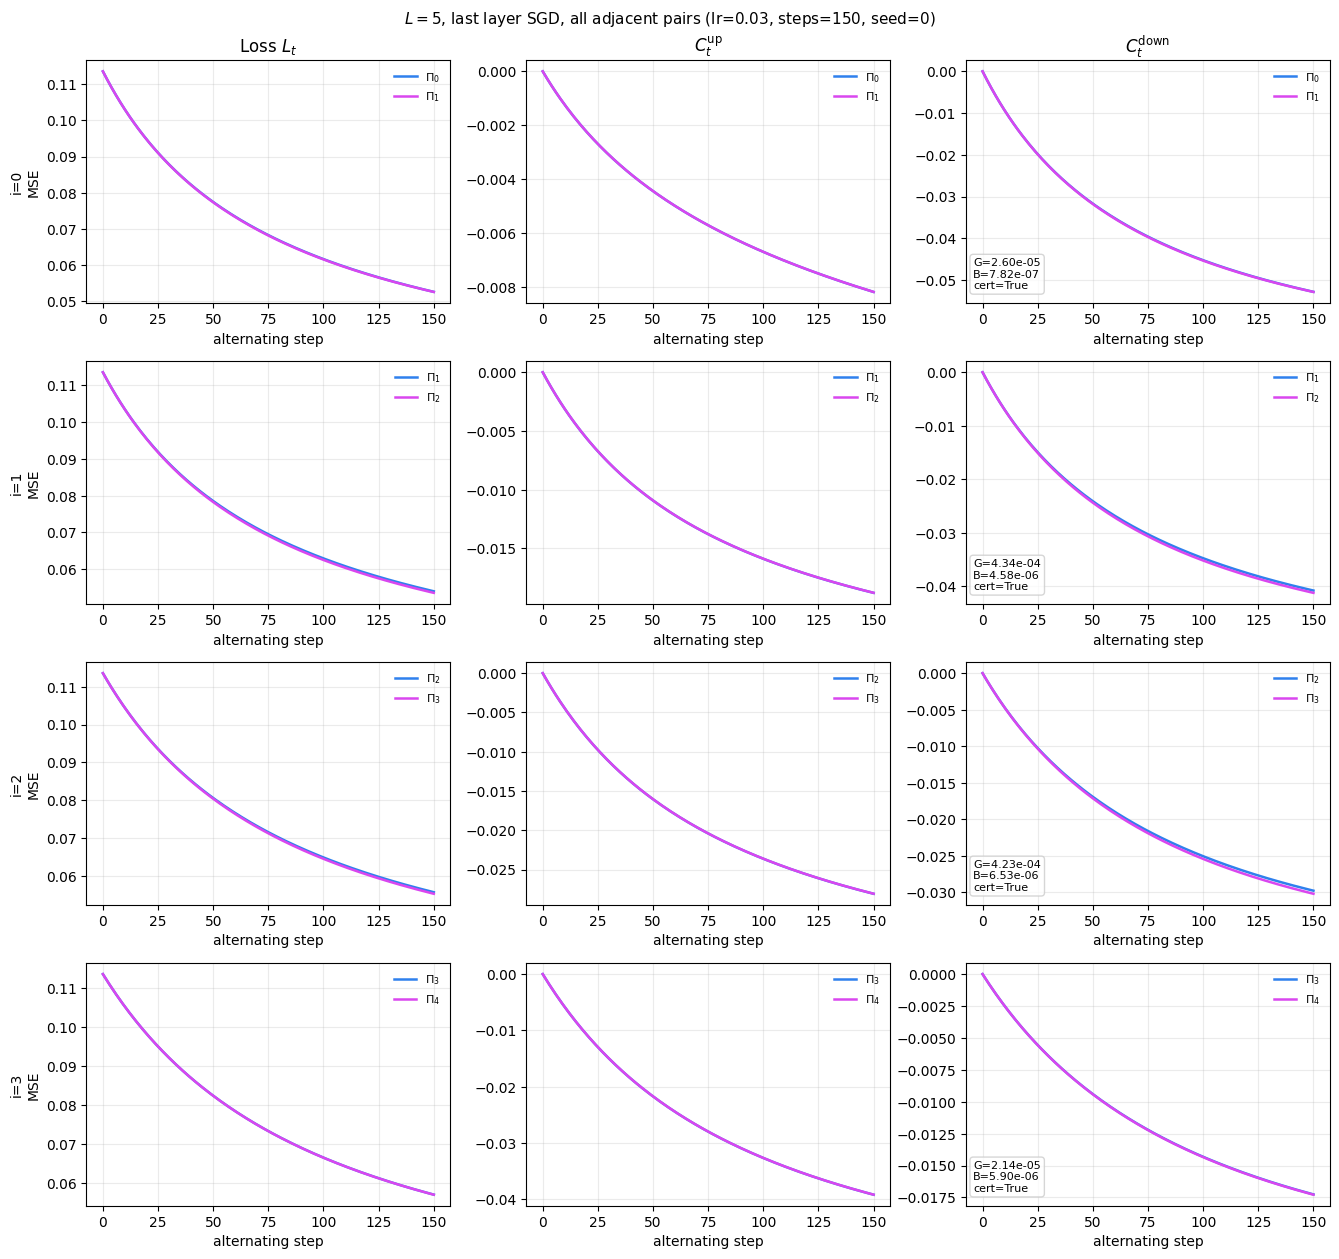

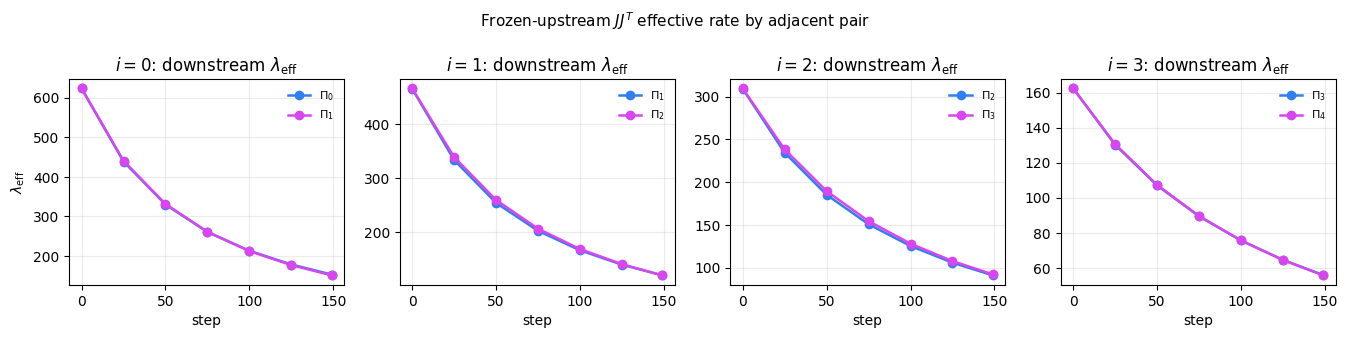

In [13]:
histories_adj = run_all_adjacent_pairs()

n_pairs = len(histories_adj)
fig, axes = plt.subplots(n_pairs, 3, figsize=(13.5, 3.2 * n_pairs), squeeze=False)
for row, hist in enumerate(histories_adj):
    i = hist["i"]
    label_a = fr"$\Pi_{{{i}}}$"
    label_b = fr"$\Pi_{{{i+1}}}$"
    steps_axis = list(range(len(hist["L_a"])))
    axes[row, 0].plot(steps_axis, hist["L_a"], color="#2F80ED", lw=1.8, label=label_a)
    axes[row, 0].plot(steps_axis, hist["L_b"], color="#D946EF", lw=1.8, label=label_b)
    axes[row, 0].set_ylabel(f"i={i}\nMSE")
    axes[row, 0].grid(True, alpha=0.25)
    axes[row, 0].legend(frameon=False, fontsize=8)
    if row == 0:
        axes[row, 0].set_title(r"Loss $L_t$")

    axes[row, 1].plot(steps_axis, hist["Cup_a"], color="#2F80ED", lw=1.8, label=label_a)
    axes[row, 1].plot(steps_axis, hist["Cup_b"], color="#D946EF", lw=1.8, label=label_b)
    axes[row, 1].grid(True, alpha=0.25)
    axes[row, 1].legend(frameon=False, fontsize=8)
    if row == 0:
        axes[row, 1].set_title(r"$C^{\mathrm{up}}_t$")

    axes[row, 2].plot(steps_axis, hist["Cdown_a"], color="#2F80ED", lw=1.8, label=label_a)
    axes[row, 2].plot(steps_axis, hist["Cdown_b"], color="#D946EF", lw=1.8, label=label_b)
    axes[row, 2].grid(True, alpha=0.25)
    axes[row, 2].legend(frameon=False, fontsize=8)
    if row == 0:
        axes[row, 2].set_title(r"$C^{\mathrm{down}}_t$")
    axes[row, 2].text(
        0.02, 0.05,
        f"G={hist['G_down']:.2e}\nB={hist['B_up']:.2e}\ncert={hist['certified']}",
        transform=axes[row, 2].transAxes, fontsize=8, va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="#ccc"),
    )
    for ax in axes[row]:
        ax.set_xlabel("alternating step")

fig.suptitle(
    fr"$L={MLP_L}$, last layer SGD, all adjacent pairs "
    fr"(lr={MLP_LR}, steps={MLP_STEPS}, seed={MLP_SEED})",
    fontsize=11,
)
fig.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, n_pairs, figsize=(3.4 * n_pairs, 3.4), squeeze=False)
for col, hist in enumerate(histories_adj):
    i = hist["i"]
    ax = axes2[0, col]
    ax.plot(hist["lambda_steps"], hist["lambda_a"], "o-", color="#2F80ED", lw=1.8, label=fr"$\Pi_{{{i}}}$")
    ax.plot(hist["lambda_steps"], hist["lambda_b"], "o-", color="#D946EF", lw=1.8, label=fr"$\Pi_{{{i+1}}}$")
    ax.set_title(fr"$i={i}$: downstream $\lambda_{{\mathrm{{eff}}}}$")
    ax.set_xlabel("step")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
axes2[0, 0].set_ylabel(r"$\lambda_{\mathrm{eff}}$")
fig2.suptitle("Frozen-upstream $JJ^T$ effective rate by adjacent pair", fontsize=11)
fig2.tight_layout()
plt.show()


### 解读可运行检查

该实验使用 $L=5$、$\tanh$ 和样本 MSE，并在每种方案中都让 $W_5$ 使用 SGD。它比较 $i=0,1,2,3$ 时的**全部**相邻方案对 $(\Pi_i,\Pi_{i+1})$。通过线搜索 $\Pi_{i+1}$ 的步长来匹配上游下降量，因此每一对的 $C^{\mathrm{up}}$ 曲线都保持接近，且 $B^{\mathrm{up}}=\sum|\delta^{\mathrm{up}}_i-\delta^{\mathrm{up}}_{i+1}|$ 很小。当 $G=C^{\mathrm{down}}(\Pi_i)-C^{\mathrm{down}}(\Pi_{i+1})$ 超过对应的 $B^{\mathrm{up}}$ 时，该相邻对通过判据。

如果打印出的每一对都显示 `cert=True`，则在这一随机种子和运行步数下，链条 $\Pi_0\to\Pi_1\to\Pi_2\to\Pi_3\to\Pi_4$ 给出交替动力学下所声称的排序。$\lambda_{\mathrm{eff}}$ 面板与黑盒 Jacobian 一节中冻结上游的诊断相同。对于 CE，只需将 $JJ^\top$ 替换为 $SJJ^\top$（或 Gauss--Newton），相邻方案 / 半步核算保持不变。
